In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wandb

from opensoundscape import CNN
from opensoundscape.data_selection import resample
from opensoundscape.preprocess.preprocessors import SpectrogramPreprocessor
from opensoundscape.preprocess.utils import show_tensor

In [3]:
TRAIN_PATH = Path("/media/auk/projects/gak76/vira_beg_outputs/training_data/splits/train_1s_gk.pkl")
TEST_PATH = Path("/media/auk/projects/gak76/vira_beg_outputs/training_data/splits/test_1s_gk.pkl")
FIELD_PATH = Path("/media/auk/projects/gak76/vira_beg_outputs/training_data/field_negatives/field_negatives_gk.pkl")

FULL_DATA_PATH = Path("/media/auk/projects/gak76/vira_beg_outputs/training_data/fulltrain/full_dataset_1s_gk.pkl")
SPLIT_DIR = Path("/media/auk/projects/gak76/vira_beg_outputs/training_data/splits")

TRAINING_OUTPUT_DIR = Path("/media/auk/projects/gak76/vira_beg_outputs/training_runs")
TRAINING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
train_df = pd.read_pickle(TRAIN_PATH)
test_df = pd.read_pickle(TEST_PATH)

print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

train_df shape: (73944, 32)
test_df shape: (18995, 32)


amhgul1  \
file                                               start_time end_time            
/home/brg226/projects/vira_beg/training_data/an... 0.481836   1.481836        0   
                                                   1.684151   2.684151        0   
                                                   2.723180   3.723180        0   
                                                   4.061076   5.061076        0   
                                                   4.290522   5.290522        0   

                                                                        bkcchi  \
file                                               start_time end_time           
/home/brg226/projects/vira_beg/training_data/an... 0.481836   1.481836       0   
                                                   1.684151   2.684151       0   
                                                   2.723180   3.723180       0   
                                                   4.061076   5.061076       0   
                                                   4.290522   5.290522       0   

                                                                        blujay  \
file                                               start_time end_time           
/home/brg226/projects/vira_beg/training_data/an... 0.481836   1.481836       0   
                                                   1.684151   2.684151       0   
                                                   2.723180   3.723180       0   
                                                   4.061076   5.061076       0   
                                                   4.290522   5.290522       0   

                                                                        cedwax  \
file                                               start_time end_time           
/home/brg226/projects/vira_beg/training_data/an... 0.481836   1.481836       0   
                                                   1.684151   2.684151       0   
                                                   2.723180   3.723180       0   
                                                   4.061076   5.061076       0   
                                                   4.290522   5.290522       0   

                                                                        comgal1  \
file                                               start_time end_time            
/home/brg226/projects/vira_beg/training_data/an... 0.481836   1.481836        0   
                                                   1.684151   2.684151        0   
                                                   2.723180   3.723180        0   
                                                   4.061076   5.061076        0   
                                                   4.290522   5.290522        0   

                                                                        comgra  \
file                                               start_time end_time           
/home/brg226/projects/vira_beg/training_data/an... 0.481836   1.481836       0   
                                                   1.684151   2.684151       0   
                                                   2.723180   3.723180       0   
                                                   4.061076   5.061076       0   
                                                   4.290522   5.290522       0   

                                                                        comyel  \
file                                               start_time end_time           
/home/brg226/projects/vira_beg/training_data/an... 0.481836   1.481836       0   
                                                   1.684151   2.684151       0   
                                                   2.723180   3.723180       0   
                                                   4.061076   5.061076       0   
                                                   4.290522   5.290522       0   

                                 

amhgul1  \
file                                               start_time end_time            
/home/brg226/projects/vira_beg/training_data/an... 0.378303   1.378303        0   
                                                   0.876813   1.876813        0   
                                                   2.164027   3.164027        0   
                                                   3.380698   4.380698        0   
                                                   4.314080   5.314080        0   

                                                                        bkcchi  \
file                                               start_time end_time           
/home/brg226/projects/vira_beg/training_data/an... 0.378303   1.378303       0   
                                                   0.876813   1.876813       0   
                                                   2.164027   3.164027       0   
                                                   3.380698   4.380698       0   
                                                   4.314080   5.314080       0   

                                                                        blujay  \
file                                               start_time end_time           
/home/brg226/projects/vira_beg/training_data/an... 0.378303   1.378303       0   
                                                   0.876813   1.876813       0   
                                                   2.164027   3.164027       0   
                                                   3.380698   4.380698       0   
                                                   4.314080   5.314080       0   

                                                                        cedwax  \
file                                               start_time end_time           
/home/brg226/projects/vira_beg/training_data/an... 0.378303   1.378303       0   
                                                   0.876813   1.876813       0   
                                                   2.164027   3.164027       0   
                                                   3.380698   4.380698       0   
                                                   4.314080   5.314080       0   

                                                                        comgal1  \
file                                               start_time end_time            
/home/brg226/projects/vira_beg/training_data/an... 0.378303   1.378303        0   
                                                   0.876813   1.876813        0   
                                                   2.164027   3.164027        0   
                                                   3.380698   4.380698        0   
                                                   4.314080   5.314080        0   

                                                                        comgra  \
file                                               start_time end_time           
/home/brg226/projects/vira_beg/training_data/an... 0.378303   1.378303       0   
                                                   0.876813   1.876813       0   
                                                   2.164027   3.164027       0   
                                                   3.380698   4.380698       0   
                                                   4.314080   5.314080       0   

                                                                        comyel  \
file                                               start_time end_time           
/home/brg226/projects/vira_beg/training_data/an... 0.378303   1.378303       0   
                                                   0.876813   1.876813       0   
                                                   2.164027   3.164027       0   
                                                   3.380698   4.380698       0   
                                                   4.314080   5.314080       0   

                                 

In [5]:
if not isinstance(train_df.index, pd.MultiIndex):
    train_df = train_df.set_index(["file", "start_time", "end_time"])

if not isinstance(test_df.index, pd.MultiIndex):
    test_df = test_df.set_index(["file", "start_time", "end_time"])

print("train index names:", train_df.index.names)
print("test index names:", test_df.index.names)

train index names: ['file', 'start_time', 'end_time']
test index names: ['file', 'start_time', 'end_time']


In [6]:
print("Training virail counts before upsampling:")
print(train_df["virail"].value_counts(dropna=False))

print("\nTest virail counts:")
print(test_df["virail"].value_counts(dropna=False))

Training virail counts before upsampling:
virail
0    73700
1      244
Name: count, dtype: int64

Test virail counts:
virail
0    18966
1       29
Name: count, dtype: int64


In [10]:
train_labels_df = train_df[["virail"]].copy()
test_labels_df = test_df[["virail"]].copy()

train_path_df_40926 = SPLIT_DIR / "train_df_gk_40926.pkl"
test_path_df_40926 = SPLIT_DIR / "test_df_gk_40926.pkl"

train_labels_df.to_pickle(train_path_df_40926)
test_labels_df.to_pickle(test_path_df_40926)

print("Saved train to:", train_path_df_40926)
print("Saved test to:", test_path_df_40926)

loaded_train_40926 = pd.read_pickle(train_path_df_40926)
loaded_test_40926 = pd.read_pickle(test_path_df_40926)

print(loaded_train_40926.head())
print(loaded_test_40926.head())

Saved train to: /media/auk/projects/gak76/vira_beg_outputs/training_data/splits/train_df_gk_40926.pkl
Saved test to: /media/auk/projects/gak76/vira_beg_outputs/training_data/splits/test_df_gk_40926.pkl
                                                                        virail
file                                               start_time end_time        
/home/brg226/projects/vira_beg/training_data/an... 0.481836   1.481836       1
                                                   1.684151   2.684151       1
                                                   2.723180   3.723180       1
                                                   4.061076   5.061076       1
                                                   4.290522   5.290522       1
                                                                        virail
file                                               start_time end_time        
/home/brg226/projects/vira_beg/training_data/an... 0.378303   1.378303       1
        

In [14]:
n_pos_train_40926 = int(train_labels_df["virail"].sum())
print(f"Number of positives in training set: {n_pos_40926}")

balanced_train_df_40926 = resample(
    train_labels_df,
    n_samples_per_class=n_pos_train_40926,
    n_samples_without_labels=n_pos_train_40926 * 12,
    random_state=0
)

print("Balanced train counts:")
print(balanced_train_df_40926["virail"].value_counts(dropna=False))



Number of positives in training set: 244
Balanced train counts:
virail
0    2928
1     244
Name: count, dtype: int64


In [15]:
n_pos_test_40926 = int(test_labels_df["virail"].sum())
print(f"Number of positives in training set: {n_pos_test_40926}")

balanced_test_df_40926 = resample(
    test_labels_df,
    n_samples_per_class=n_pos_test_40926,
    n_samples_without_labels=n_pos_test_40926 * 12,
    random_state=0
)

print("Balanced train counts:")
print(balanced_test_df_40926["virail"].value_counts(dropna=False))

Number of positives in training set: 29
Balanced train counts:
virail
0    348
1     29
Name: count, dtype: int64


In [17]:
shallow_train_path_df_40926 = SPLIT_DIR / "shallow_train_df_gk_40926.pkl"
shallow_test_path_df_40926 = SPLIT_DIR / "shallow_test_df_gk_40926.pkl"

balanced_train_df_40926.to_pickle(shallow_train_path_df_40926)
balanced_test_df_40926.to_pickle(shallow_test_path_df_40926)

print("Saved train to:", shallow_train_path_df_40926)
print("Saved test to:", shallow_test_path_df_40926)

shallow_loaded_train_40926 = pd.read_pickle(shallow_train_path_df_40926)
shallow_loaded_test_40926 = pd.read_pickle(shallow_test_path_df_40926)

print(shallow_loaded_train_40926.head())
print(shallow_loaded_test_40926.head())

Saved train to: /media/auk/projects/gak76/vira_beg_outputs/training_data/splits/shallow_train_df_gk_40926.pkl
Saved test to: /media/auk/projects/gak76/vira_beg_outputs/training_data/splits/shallow_test_df_gk_40926.pkl
                                                                        virail
file                                               start_time end_time        
/home/brg226/projects/vira_beg/training_data/an... 0.481836   1.481836       1
                                                   1.684151   2.684151       1
                                                   2.723180   3.723180       1
                                                   4.061076   5.061076       1
                                                   4.290522   5.290522       1
                                                                        virail
file                                               start_time end_time        
/home/brg226/projects/vira_beg/training_data/an... 0.378303   1.378303 

In [7]:
#balanced_train_df = resample(
#    train_labels_df,
#    n_samples_per_class=10000,
#    n_samples_without_labels=10000,
#    random_state=0
#)

In [8]:
n_pos = int(train_labels_df["virail"].sum())
print(f"Number of positives in training set: {n_pos}")

balanced_train_df = resample(
    train_labels_df,
    n_samples_per_class=n_pos*3,
    n_samples_without_labels=n_pos * 10,
    random_state=0
)

print("Balanced train counts:")
print(balanced_train_df["virail"].value_counts(dropna=False))

Number of positives in training set: 244
Balanced train counts:
virail
0    2440
1     732
Name: count, dtype: int64


In [9]:
print("Original train counts:")
print(train_df["virail"].value_counts())

print("\nBalanced train counts:")
print(balanced_train_df["virail"].value_counts())
print("Shape:", balanced_train_df.shape)
print(balanced_train_df["virail"].value_counts(dropna=False))
print("Rows with no labels:", int((balanced_train_df.sum(axis=1) == 0).sum()))

Original train counts:
virail
0    73700
1      244
Name: count, dtype: int64

Balanced train counts:
virail
0    2440
1     732
Name: count, dtype: int64
Shape: (3172, 1)
virail
0    2440
1     732
Name: count, dtype: int64
Rows with no labels: 2440


In [10]:
print("positive rows:", int((balanced_train_df["virail"] == 1).sum()))
print("negative rows:", int((balanced_train_df.sum(axis=1) == 0).sum()))

positive rows: 732
negative rows: 2440


In [11]:
display(balanced_train_df.head(300))

virail
file                                               start_time end_time         
/home/brg226/projects/vira_beg/training_data/an... 0.481836   1.481836        1
                                                   1.684151   2.684151        1
                                                   2.723180   3.723180        1
                                                   4.061076   5.061076        1
                                                   4.290522   5.290522        1
...                                                                         ...
/home/brg226/projects/vira_beg/training_data/an... 17.603430  18.603430       1
                                                   19.945277  20.945277       1
                                                   21.000299  22.000299       1
/home/brg226/projects/vira_beg/training_data/an... 81.107338  82.107338       1
                                                   89.703466  90.703466       1

[300 rows x 1 columns]

In [12]:
UPSAMPLED_DIR = TRAINING_OUTPUT_DIR / "upsampled_data"
UPSAMPLED_DIR.mkdir(parents=True, exist_ok=True)

balanced_train_df.to_pickle(UPSAMPLED_DIR / "balanced_train_1s_gk.pkl")
balanced_train_df.reset_index().to_csv(UPSAMPLED_DIR / "balanced_train_1s_gk.csv", index=False)

print("Saved balanced training set.")

Saved balanced training set.


In [13]:
field_df = pd.read_pickle(FIELD_PATH)

if not isinstance(field_df.index, pd.MultiIndex):
    field_df = field_df.set_index(["file", "start_time", "end_time"])

#overlay_df = field_df[[]].copy()
overlay_df = pd.DataFrame(index=field_df.index)

print("overlay_df shape:", overlay_df.shape)
display(overlay_df.head())

overlay_df shape: (29700, 0)


Empty DataFrame
Columns: []
Index: [(/media/kiwi/datasets/unfinalized/rloc2025a/MSD-3593/20250509_120000.WAV, 0.0, 1.0), (/media/kiwi/datasets/unfinalized/rloc2025a/MSD-3593/20250509_120000.WAV, 1.0, 2.0), (/media/kiwi/datasets/unfinalized/rloc2025a/MSD-3593/20250509_120000.WAV, 2.0, 3.0), (/media/kiwi/datasets/unfinalized/rloc2025a/MSD-3593/20250509_120000.WAV, 3.0, 4.0), (/media/kiwi/datasets/unfinalized/rloc2025a/MSD-3593/20250509_120000.WAV, 4.0, 5.0)]

In [14]:
my_preprocessor = SpectrogramPreprocessor(1.0, overlay_df=overlay_df)

for name in ["random_affine", "add_noise"]:
    try:
        my_preprocessor.remove_action(name)
        print(f"Removed action: {name}")
    except Exception:
        print(f"Could not remove action: {name}")

Removed action: random_affine
Removed action: add_noise


In [15]:
my_preprocessor.sample_rate = 32000

my_preprocessor.pipeline.bandpass.set(min_f=2000, max_f=7000)
#my_preprocessor.pipeline.overlay.set(weight=0.5)
my_preprocessor.pipeline.overlay.set(overlay_weight=0.3)


print(my_preprocessor)

Preprocessor with pipeline:
load_audio           Action calling <bound method Audio.from_file o...
random_trim_audio    Augmentation Action calling <function trim_aud...
trim_audio           Action calling <function trim_audio at 0x7f820...
to_spec              Action calling <bound method Spectrogram.from_...
bandpass             Action calling <function Spectrogram.bandpass ...
to_tensor            Action calling <function Spectrogram.to_image ...
overlay              Augmentation Action calling <function overlay ...
time_mask            Augmentation Action calling <function time_mas...
frequency_mask       Augmentation Action calling <function frequenc...
rescale              Action calling <function scale_tensor at 0x7f8...
dtype: object


In [16]:
class_list = list(balanced_train_df.columns)

model = CNN(
    architecture="resnet18",
    classes=class_list,
    sample_duration=1.0,
)

model.preprocessor = my_preprocessor
print(model)

CNN(
  (network): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [17]:
species_cols = [col for col in test_df.columns if col != "virail"]
print("Species columns available:", species_cols[:10])  # preview first 10

Species columns available: ['amhgul1', 'bkcchi', 'blujay', 'cedwax', 'comgal1', 'comgra', 'comyel', 'easkin', 'easpho', 'eawpew']



Sample 0
labels:
virail    True
Name: (/home/brg226/projects/vira_beg/training_data/annotated_positive_audio/audio_viratrain/463875351.wav, 10.340766418, 11.340766418), dtype: bool


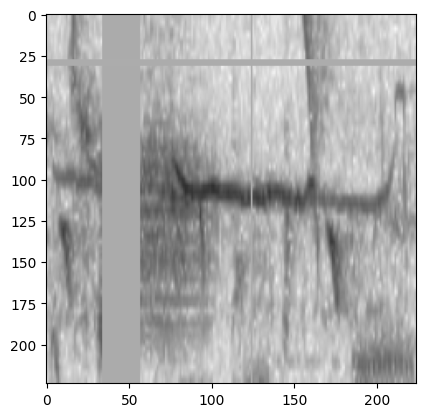


Sample 1
labels:
virail    False
Name: (/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0028.tar.gz/XC134099.ogg, 24.256, 25.256), dtype: bool


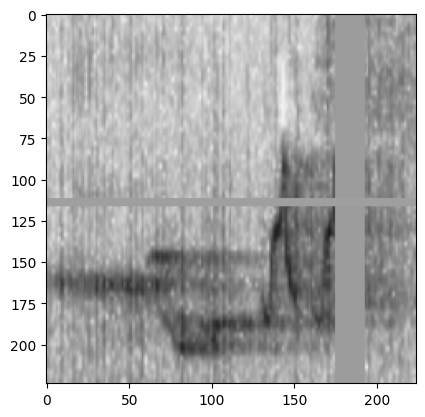


Sample 2
labels:
virail    False
Name: (/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0028.tar.gz/XC526707.ogg, 10.224, 11.224), dtype: bool


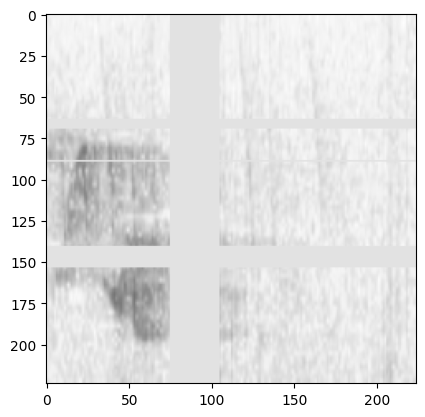


Sample 3
labels:
virail    False
Name: (/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0084.tar.gz/XC363213.ogg, 7.408, 8.408000000000001), dtype: bool


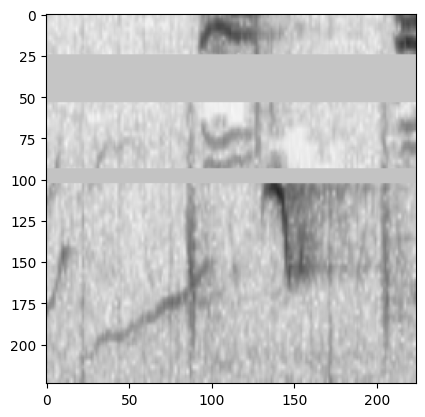


Sample 4
labels:
virail    False
Name: (/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0011.tar.gz/XC691878.ogg, 38.736, 39.736), dtype: bool


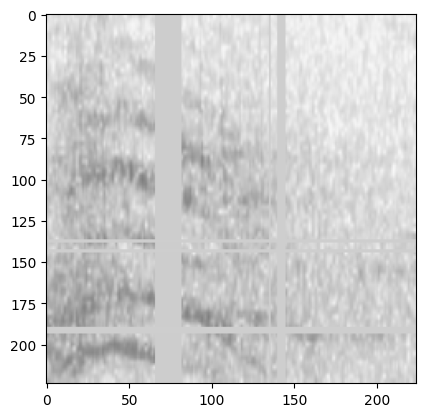


Sample 5
labels:
virail    False
Name: (/media/kiwi/datasets/unfinalized/rloc2025a/MSD-2545/20250529_030000.WAV, 470.0, 471.0), dtype: bool


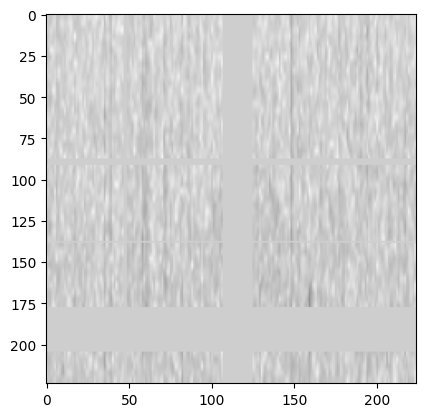


Sample 6
labels:
virail    False
Name: (/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0090.tar.gz/XC623986.ogg, 9.936, 10.936), dtype: bool


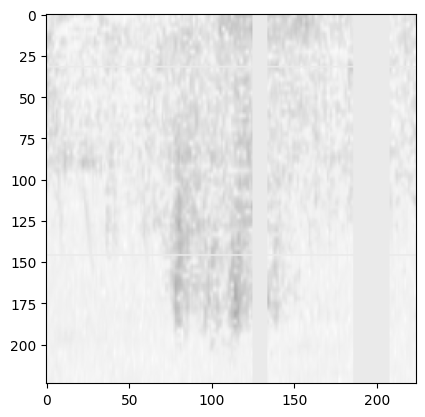


Sample 7
labels:
virail    False
Name: (/media/kiwi/datasets/unfinalized/rloc2025a/MSD-3682/20250520_070000.WAV, 563.0, 564.0), dtype: bool


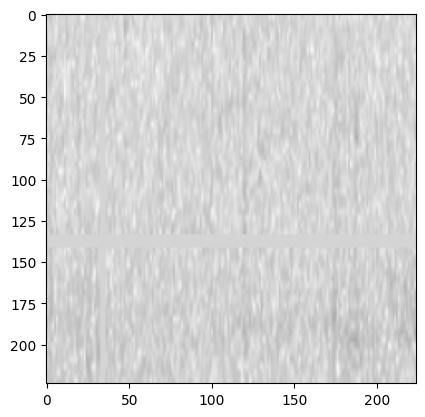


Sample 8
labels:
virail    False
Name: (/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0025.tar.gz/XC174969.ogg, 12.112, 13.112), dtype: bool


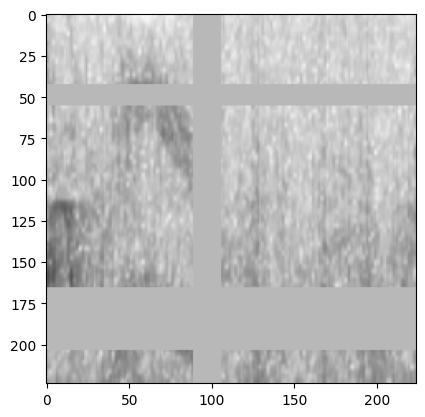


Sample 9
labels:
virail    False
Name: (/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0008.tar.gz/XC172443.ogg, 8.56, 9.56), dtype: bool


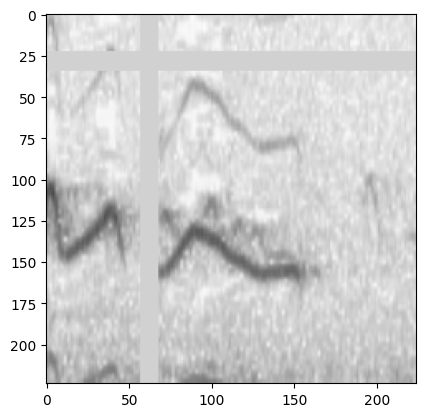


Sample 10
labels:
virail    True
Name: (/home/brg226/projects/vira_beg/training_data/annotated_positive_audio/audio_viratrain/104728661.wav, 25.256040675, 26.256040675), dtype: bool


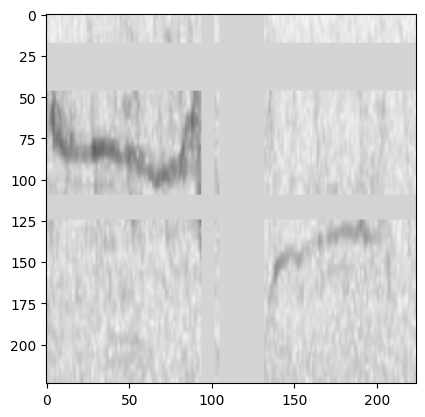


Sample 11
labels:
virail    False
Name: (/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0025.tar.gz/XC135711.ogg, 74.48, 75.48), dtype: bool


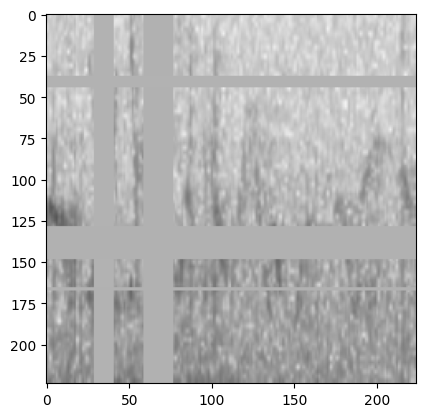


Sample 12
labels:
virail    False
Name: (/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0028.tar.gz/XC185285.ogg, 0.016, 1.016), dtype: bool


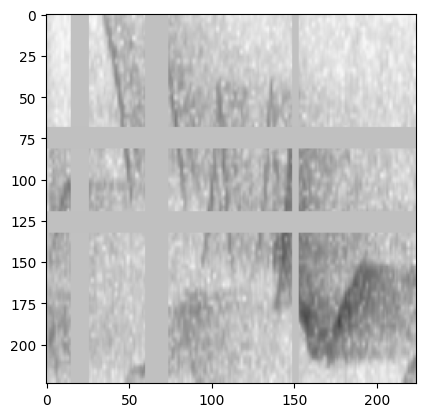


Sample 13
labels:
virail    False
Name: (/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0007.tar.gz/XC413399.ogg, 15.04, 16.04), dtype: bool


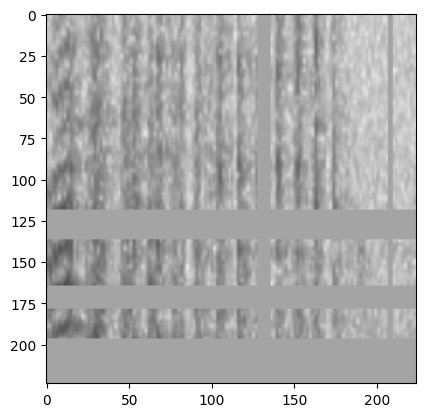


Sample 14
labels:
virail    False
Name: (/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0084.tar.gz/XC798761.ogg, 48.32, 49.32), dtype: bool


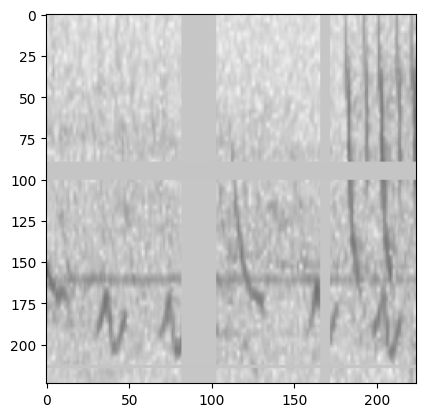


Sample 15
labels:
virail    False
Name: (/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0037.tar.gz/XC324938.ogg, 20.544, 21.544), dtype: bool


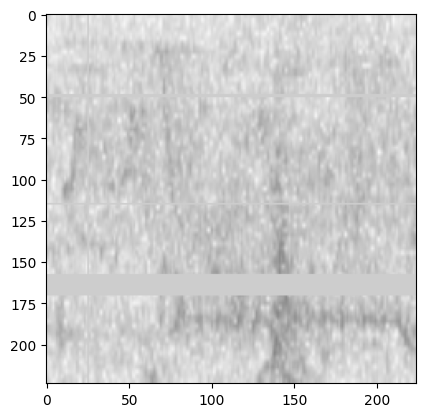


Sample 16
labels:
virail    True
Name: (/home/brg226/projects/vira_beg/training_data/annotated_positive_audio/audio_viratrain/360319041.wav, 5.795232882, 6.795232882), dtype: bool


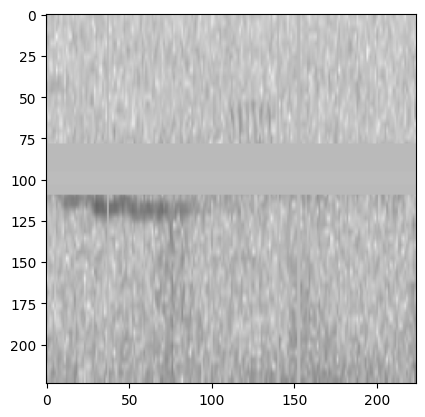


Sample 17
labels:
virail    True
Name: (/home/brg226/projects/vira_beg/training_data/annotated_positive_audio/audio_viratrain/463875361.wav, 13.636229548, 14.636229548), dtype: bool


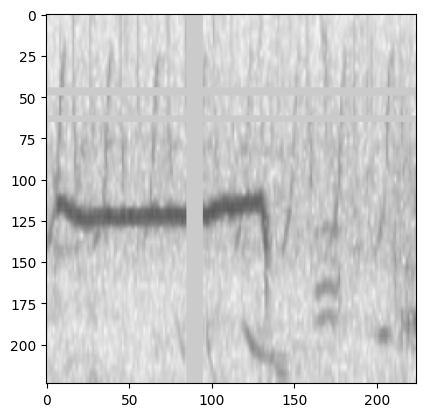


Sample 18
labels:
virail    True
Name: (/home/brg226/projects/vira_beg/training_data/annotated_positive_audio/audio_viratrain/360319081.wav, 0.344690113, 1.344690113), dtype: bool


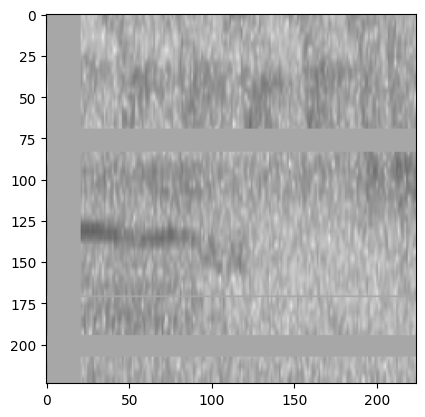


Sample 19
labels:
virail    False
Name: (/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0028.tar.gz/XC564808.ogg, 37.824, 38.824), dtype: bool


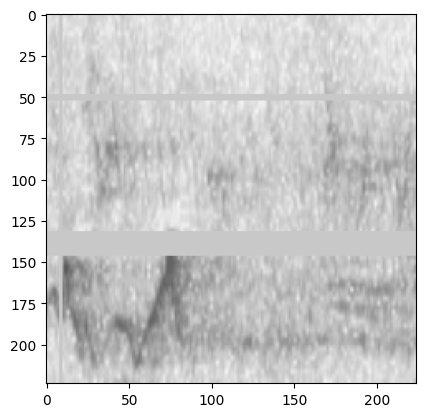

In [18]:
samples = model.generate_samples(
    balanced_train_df.sample(20, random_state=0),
    bypass_augmentations=False
)

for i, sample in enumerate(samples):
    print(f"\nSample {i}")
    print("labels:")
    print(sample.labels)
    show_tensor(sample.data)
    plt.show()


Training Epoch 0


/home/sml161/miniconda3/envs/perch2/lib/python3.11/site-packages/opensoundscape/ml/cnn.py:1510: UserWarning: No validation set was provided. Model will be evaluated using the performance on the training set.
  warnings.warn(


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 0 [batch 0/50, 0.00%] 
	Epoch Running Average Loss: 0.639
	Most Recent Batch Loss: 0.639

Training Epoch 1


  0%|          | 0/50 [00:00<?, ?it/s]

...

Epoch: 17 [batch 0/50, 0.00%] 
	Epoch Running Average Loss: 0.001
	Most Recent Batch Loss: 0.001

Training Epoch 18


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 18 [batch 0/50, 0.00%] 
	Epoch Running Average Loss: 0.001
	Most Recent Batch Loss: 0.001

Training Epoch 19


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 19 [batch 0/50, 0.00%] 
	Epoch Running Average Loss: 0.000
	Most Recent Batch Loss: 0.000

Best Model Appears at Epoch 18 with Validation score 1.000.


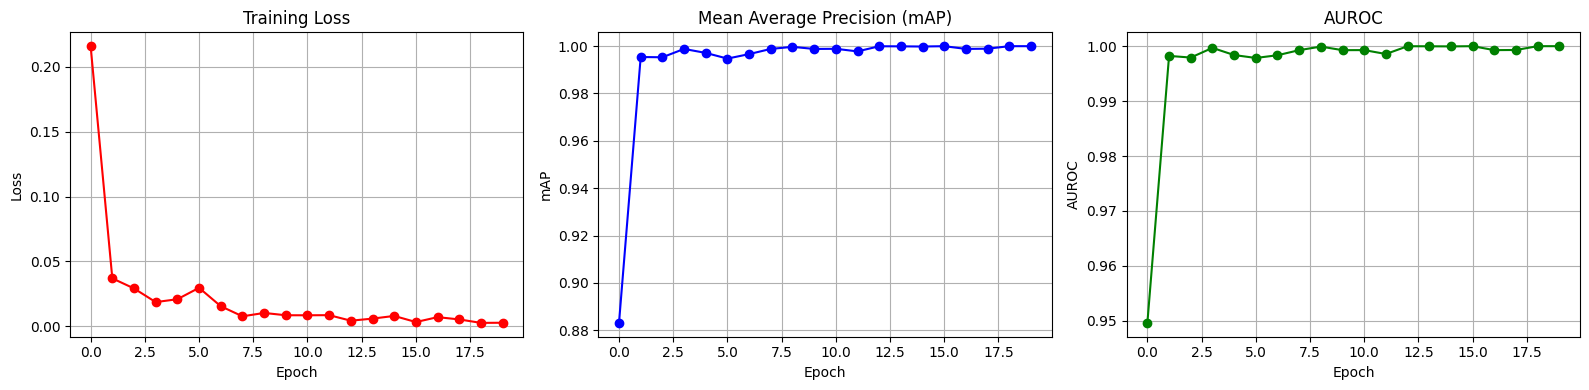

/home/sml161/miniconda3/envs/perch2/lib/python3.11/site-packages/opensoundscape/ml/cnn.py:1075: UserWarning: The columns of input samples df differ from `model.classes`.
  warnings.warn(


  0%|          | 0/18995 [00:00<?, ?it/s]

Threshold sweep:
Threshold    Precision    Recall       F1          
Threshold 0.950 | Precision: 0.82 | Recall: 0.93 | F1: 0.87
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00     18966
      virail       0.39      1.00      0.56        29

    accuracy                           1.00     18995
   macro avg       0.69      1.00      0.78     18995
weighted avg       1.00      1.00      1.00     18995

ROC-AUC: 0.9999509103404641


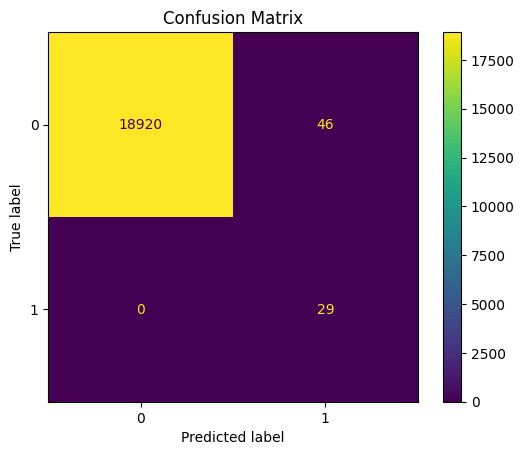

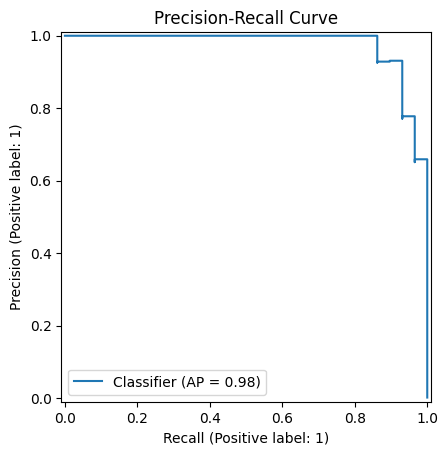


Total false positives: 46

Top false positives by confidence score:


,file,start_time,end_time,pred_score
12895,/media/kiwi/datasets/unfinalized/rloc2025a/MSD...,200.000,201.000,0.996463
15837,/media/kiwi/datasets/unfinalized/rloc2025a/MSD...,442.000,443.000,0.995223
9485,/media/kiwi/datasets/annotated/xeno_canto_snap...,27.920,28.920,0.986783
9483,/media/kiwi/datasets/annotated/xeno_canto_snap...,11.504,12.504,0.985934
9482,/media/kiwi/datasets/annotated/xeno_canto_snap...,7.984,8.984,0.983074
9488,/media/kiwi/datasets/annotated/xeno_canto_snap...,45.456,46.456,0.971540
17849,/media/kiwi/datasets/unfinalized/rloc2025a/MSD...,654.000,655.000,0.933915
9486,/media/kiwi/datasets/annotated/xeno_canto_snap...,29.776,30.776,0.927579
9490,/media/kiwi/datasets/annotated/xeno_canto_snap...,60.160,61.160,0.907161
9484,/media/kiwi/datasets/annotated/xeno_canto_snap...,21.312,22.312,0.902229



False positives by file:
file
/media/kiwi/datasets/unfinalized/rloc2025a/MSD-3645/20250526_110000.WAV                                                                                                                                        15
/media/kiwi/datasets/unfinalized/rloc2025a/MSD-2774/20250518_100000.WAV                                                                                                                                         9
/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0072.tar.gz/XC737194.ogg     9
/media/kiwi/datasets/unfinalized/rloc2025a/MSD-3754/20250516_000000.WAV                                                                                                                                         8
/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e

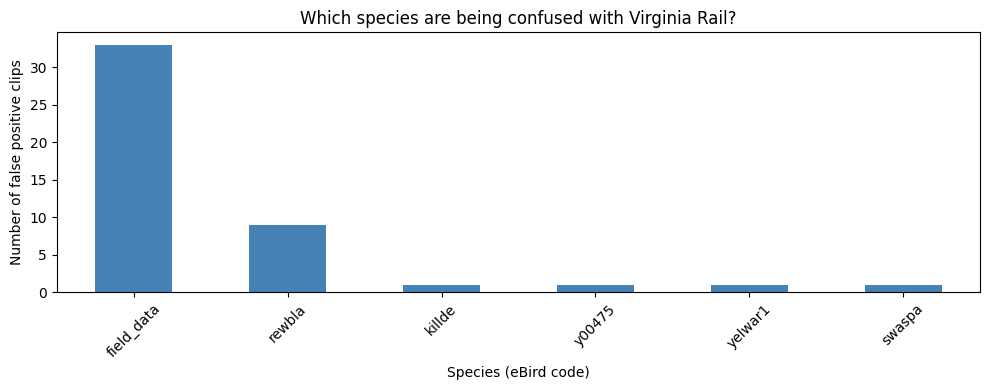


Spectrograms of top 6 false positives:


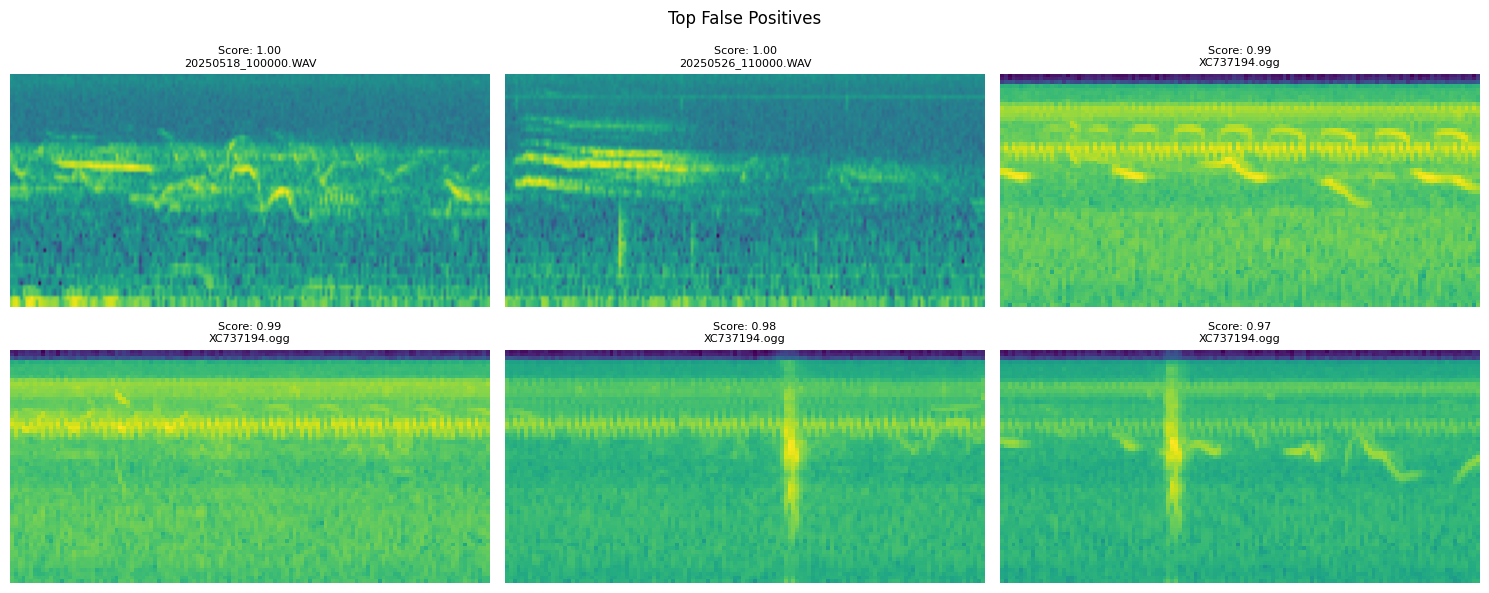

In [19]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, PrecisionRecallDisplay, precision_score, recall_score

checkpoint_folder = Path("model_training_checkpoints")
checkpoint_folder.mkdir(exist_ok=True)

# --- Train ONCE ---
model.train(
    balanced_train_df,
    epochs=20,
    batch_size=64,
    log_interval=100,
    num_workers=4,
    save_interval=1,
    save_path=checkpoint_folder,
)

# --- Plot training curves ---
epochs = list(model.loss_hist.keys())
losses = list(model.loss_hist.values())
map_scores = [model.train_metrics[e]['map'].item() for e in epochs]
auroc_scores = [model.train_metrics[e]['auroc'].item() for e in epochs]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(epochs, losses, marker='o', color='red')
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(epochs, map_scores, marker='o', color='blue')
axes[1].set_title("Mean Average Precision (mAP)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP")
axes[1].grid(True)

axes[2].plot(epochs, auroc_scores, marker='o', color='green')
axes[2].set_title("AUROC")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUROC")
axes[2].grid(True)

plt.tight_layout()
plt.show()

# --- Run predictions ---
preds = model.predict(test_df)

# --- Convert logits to probabilities ---
pred_scores = torch.sigmoid(torch.tensor(preds["virail"].values)).numpy()
true_labels = test_df["virail"].values

# --- Threshold sweep ---
print("Threshold sweep:")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
for threshold in [.95]:
    pl = (pred_scores >= threshold).astype(int)
    p = precision_score(true_labels, pl, zero_division=0)
    r = recall_score(true_labels, pl, zero_division=0)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    print(f"Threshold {threshold:.3f} | Precision: {p:.2f} | Recall: {r:.2f} | F1: {f1:.2f}")
# --- Pick your best threshold from sweep and use it below ---
best_threshold = 0.5  # adjust after reviewing sweep above
pred_labels = (pred_scores >= best_threshold).astype(int)

# --- Evaluation metrics ---
print(classification_report(true_labels, pred_labels, target_names=["negative", "virail"]))
print("ROC-AUC:", roc_auc_score(true_labels, pred_scores))

# --- Confusion matrix ---
ConfusionMatrixDisplay.from_predictions(true_labels, pred_labels)
plt.title("Confusion Matrix")
plt.show()

# --- Precision-Recall curve ---
PrecisionRecallDisplay.from_predictions(true_labels, pred_scores)
plt.title("Precision-Recall Curve")
plt.show()

# --- Investigate false positives ---
results_df = preds.copy().reset_index()
results_df["pred_score"] = pred_scores
results_df["pred_label"] = pred_labels
results_df["true_label"] = true_labels

false_positives = results_df[
    (results_df["pred_label"] == 1) & (results_df["true_label"] == 0)
].sort_values("pred_score", ascending=False)

print(f"\nTotal false positives: {len(false_positives)}")
print("\nTop false positives by confidence score:")
display(false_positives[["file", "start_time", "end_time", "pred_score"]].head(20))

# --- Which files are producing the most false positives? ---
fp_by_file = false_positives.groupby("file").size().sort_values(ascending=False)
print("\nFalse positives by file:")
print(fp_by_file.head(20))

# --- Which species are being confused with Virginia Rail? ---
species_cols = [col for col in test_df.columns if col != "virail"]
fp_idx = false_positives.set_index(["file", "start_time", "end_time"]).index
fp_species = test_df.loc[test_df.index.isin(fp_idx), species_cols]

species_counts = fp_species.sum().sort_values(ascending=False)
print("\nSpecies breakdown of false positives:")
print(species_counts[species_counts > 0])

species_counts[species_counts > 0].plot(kind="bar", figsize=(10, 4), color="steelblue")
plt.title("Which species are being confused with Virginia Rail?")
plt.xlabel("Species (eBird code)")
plt.ylabel("Number of false positive clips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Plot spectrograms of top 6 false positives ---
from opensoundscape.audio import Audio
from opensoundscape.spectrogram import MelSpectrogram

print("\nSpectrograms of top 6 false positives:")
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()

for i, (_, row) in enumerate(false_positives.head(6).iterrows()):
    try:
        audio = Audio.from_file(row["file"])
        clip = audio.trim(row["start_time"], row["end_time"])
        spec = MelSpectrogram.from_audio(clip)
        axes[i].imshow(spec.spectrogram, aspect="auto", origin="lower")
        axes[i].set_title(f"Score: {row['pred_score']:.2f}\n{Path(row['file']).name}", fontsize=8)
        axes[i].axis("off")
    except Exception as e:
        axes[i].set_title(f"Error: {e}", fontsize=7)
        axes[i].axis("off")

plt.suptitle("Top False Positives", fontsize=12)
plt.tight_layout()
plt.show()


Training Epoch 0


/home/sml161/miniconda3/envs/perch2/lib/python3.11/site-packages/opensoundscape/ml/cnn.py:1510: UserWarning: No validation set was provided. Model will be evaluated using the performance on the training set.
  warnings.warn(


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 0 [batch 0/50, 0.00%] 
	Epoch Running Average Loss: 0.639
	Most Recent Batch Loss: 0.639

Training Epoch 1


  0%|          | 0/50 [00:00<?, ?it/s]

...

Epoch: 17 [batch 0/50, 0.00%] 
	Epoch Running Average Loss: 0.001
	Most Recent Batch Loss: 0.001

Training Epoch 18


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 18 [batch 0/50, 0.00%] 
	Epoch Running Average Loss: 0.001
	Most Recent Batch Loss: 0.001

Training Epoch 19


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 19 [batch 0/50, 0.00%] 
	Epoch Running Average Loss: 0.000
	Most Recent Batch Loss: 0.000

Best Model Appears at Epoch 18 with Validation score 1.000.


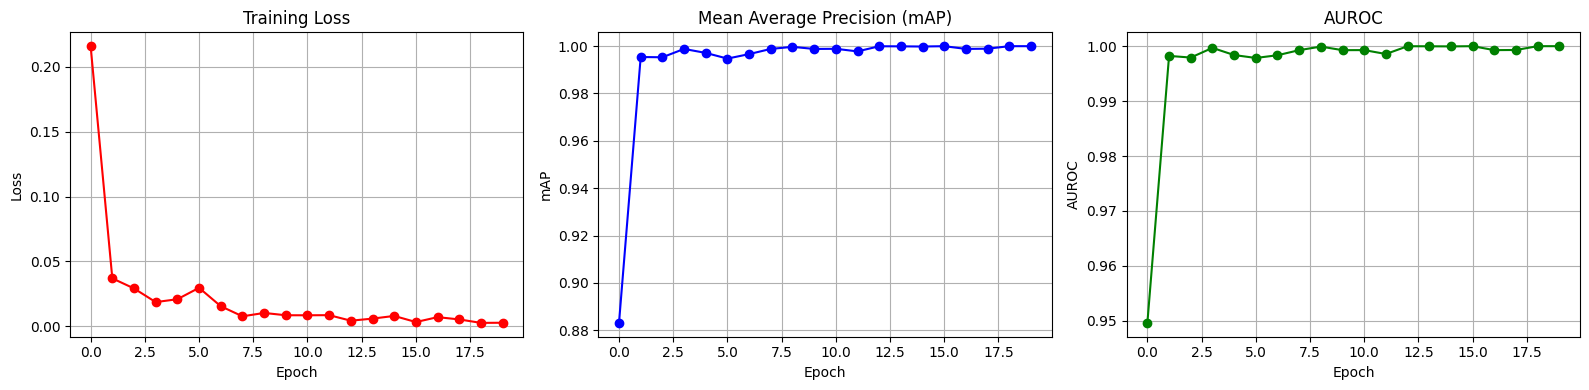

/home/sml161/miniconda3/envs/perch2/lib/python3.11/site-packages/opensoundscape/ml/cnn.py:1075: UserWarning: The columns of input samples df differ from `model.classes`.
  warnings.warn(


  0%|          | 0/18995 [00:00<?, ?it/s]

Threshold sweep:
Threshold    Precision    Recall       F1          
Threshold 0.950 | Precision: 0.82 | Recall: 0.93 | F1: 0.87
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00     18966
      virail       0.39      1.00      0.56        29

    accuracy                           1.00     18995
   macro avg       0.69      1.00      0.78     18995
weighted avg       1.00      1.00      1.00     18995

ROC-AUC: 0.9999509103404641


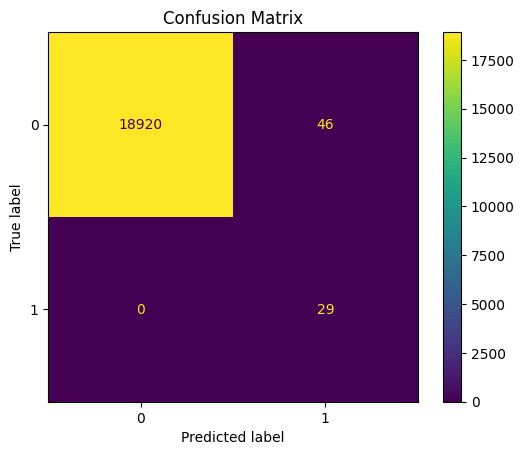

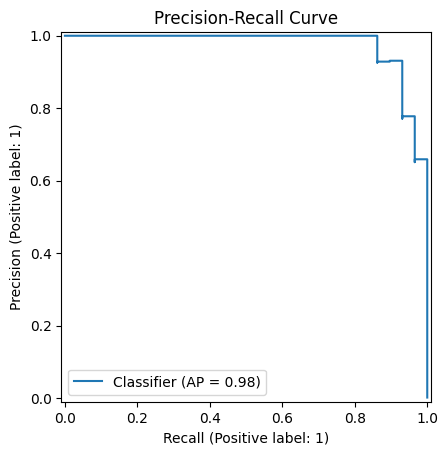


Total false positives: 46

Top false positives by confidence score:


,file,start_time,end_time,pred_score
12895,/media/kiwi/datasets/unfinalized/rloc2025a/MSD...,200.000,201.000,0.996463
15837,/media/kiwi/datasets/unfinalized/rloc2025a/MSD...,442.000,443.000,0.995223
9485,/media/kiwi/datasets/annotated/xeno_canto_snap...,27.920,28.920,0.986783
9483,/media/kiwi/datasets/annotated/xeno_canto_snap...,11.504,12.504,0.985934
9482,/media/kiwi/datasets/annotated/xeno_canto_snap...,7.984,8.984,0.983074
9488,/media/kiwi/datasets/annotated/xeno_canto_snap...,45.456,46.456,0.971540
17849,/media/kiwi/datasets/unfinalized/rloc2025a/MSD...,654.000,655.000,0.933915
9486,/media/kiwi/datasets/annotated/xeno_canto_snap...,29.776,30.776,0.927579
9490,/media/kiwi/datasets/annotated/xeno_canto_snap...,60.160,61.160,0.907161
9484,/media/kiwi/datasets/annotated/xeno_canto_snap...,21.312,22.312,0.902229



False positives by file:
file
/media/kiwi/datasets/unfinalized/rloc2025a/MSD-3645/20250526_110000.WAV                                                                                                                                        15
/media/kiwi/datasets/unfinalized/rloc2025a/MSD-2774/20250518_100000.WAV                                                                                                                                         9
/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0072.tar.gz/XC737194.ogg     9
/media/kiwi/datasets/unfinalized/rloc2025a/MSD-3754/20250516_000000.WAV                                                                                                                                         8
/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e

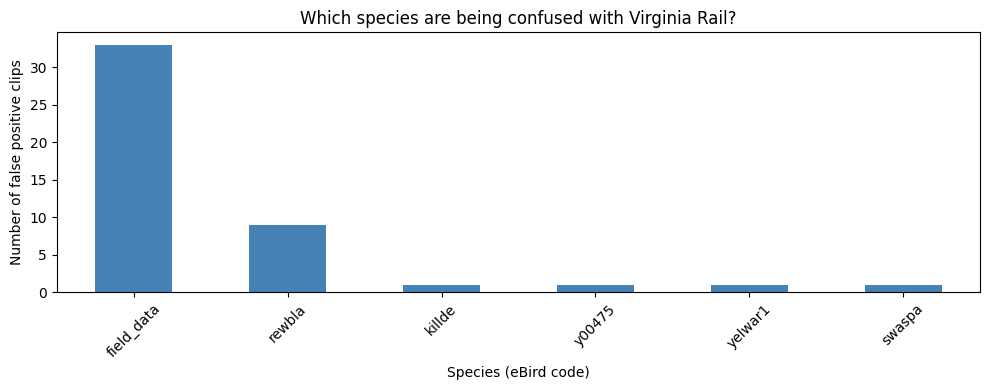


Spectrograms of top 6 false positives:


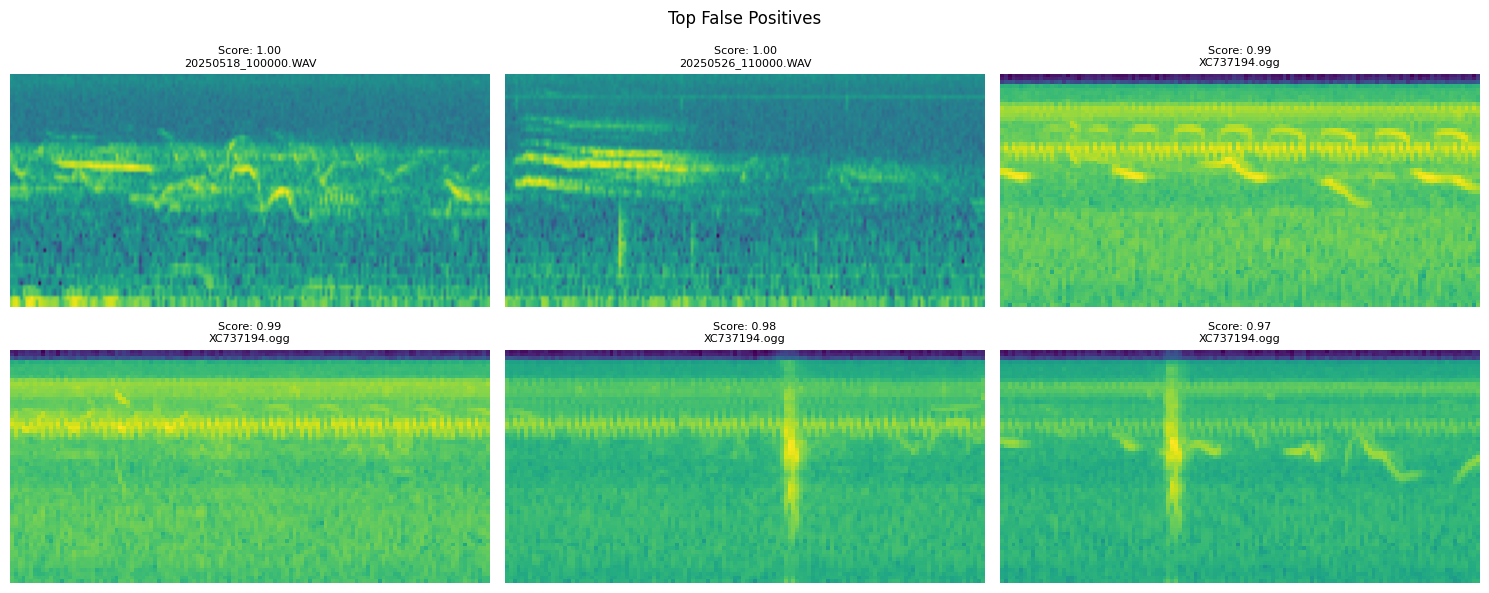

In [19]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, PrecisionRecallDisplay, precision_score, recall_score

checkpoint_folder = Path("model_training_checkpoints")
checkpoint_folder.mkdir(exist_ok=True)

# --- Train ONCE ---
model.train(
    balanced_train_df,
    epochs=20,
    batch_size=64,
    log_interval=100,
    num_workers=4,
    save_interval=1,
    save_path=checkpoint_folder,
)

# --- Plot training curves ---
epochs = list(model.loss_hist.keys())
losses = list(model.loss_hist.values())
map_scores = [model.train_metrics[e]['map'].item() for e in epochs]
auroc_scores = [model.train_metrics[e]['auroc'].item() for e in epochs]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(epochs, losses, marker='o', color='red')
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(epochs, map_scores, marker='o', color='blue')
axes[1].set_title("Mean Average Precision (mAP)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP")
axes[1].grid(True)

axes[2].plot(epochs, auroc_scores, marker='o', color='green')
axes[2].set_title("AUROC")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUROC")
axes[2].grid(True)

plt.tight_layout()
plt.show()

# --- Run predictions ---
preds = model.predict(test_df)

# --- Convert logits to probabilities ---
pred_scores = torch.sigmoid(torch.tensor(preds["virail"].values)).numpy()
true_labels = test_df["virail"].values

# --- Threshold sweep ---
print("Threshold sweep:")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
for threshold in [.95]:
    pl = (pred_scores >= threshold).astype(int)
    p = precision_score(true_labels, pl, zero_division=0)
    r = recall_score(true_labels, pl, zero_division=0)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    print(f"Threshold {threshold:.3f} | Precision: {p:.2f} | Recall: {r:.2f} | F1: {f1:.2f}")
# --- Pick your best threshold from sweep and use it below ---
best_threshold = 0.5  # adjust after reviewing sweep above
pred_labels = (pred_scores >= best_threshold).astype(int)

# --- Evaluation metrics ---
print(classification_report(true_labels, pred_labels, target_names=["negative", "virail"]))
print("ROC-AUC:", roc_auc_score(true_labels, pred_scores))

# --- Confusion matrix ---
ConfusionMatrixDisplay.from_predictions(true_labels, pred_labels)
plt.title("Confusion Matrix")
plt.show()

# --- Precision-Recall curve ---
PrecisionRecallDisplay.from_predictions(true_labels, pred_scores)
plt.title("Precision-Recall Curve")
plt.show()

# --- Investigate false positives ---
results_df = preds.copy().reset_index()
results_df["pred_score"] = pred_scores
results_df["pred_label"] = pred_labels
results_df["true_label"] = true_labels

false_positives = results_df[
    (results_df["pred_label"] == 1) & (results_df["true_label"] == 0)
].sort_values("pred_score", ascending=False)

print(f"\nTotal false positives: {len(false_positives)}")
print("\nTop false positives by confidence score:")
display(false_positives[["file", "start_time", "end_time", "pred_score"]].head(20))

# --- Which files are producing the most false positives? ---
fp_by_file = false_positives.groupby("file").size().sort_values(ascending=False)
print("\nFalse positives by file:")
print(fp_by_file.head(20))

# --- Which species are being confused with Virginia Rail? ---
species_cols = [col for col in test_df.columns if col != "virail"]
fp_idx = false_positives.set_index(["file", "start_time", "end_time"]).index
fp_species = test_df.loc[test_df.index.isin(fp_idx), species_cols]

species_counts = fp_species.sum().sort_values(ascending=False)
print("\nSpecies breakdown of false positives:")
print(species_counts[species_counts > 0])

species_counts[species_counts > 0].plot(kind="bar", figsize=(10, 4), color="steelblue")
plt.title("Which species are being confused with Virginia Rail?")
plt.xlabel("Species (eBird code)")
plt.ylabel("Number of false positive clips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Plot spectrograms of top 6 false positives ---
from opensoundscape.audio import Audio
from opensoundscape.spectrogram import MelSpectrogram

print("\nSpectrograms of top 6 false positives:")
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()

for i, (_, row) in enumerate(false_positives.head(6).iterrows()):
    try:
        audio = Audio.from_file(row["file"])
        clip = audio.trim(row["start_time"], row["end_time"])
        spec = MelSpectrogram.from_audio(clip)
        axes[i].imshow(spec.spectrogram, aspect="auto", origin="lower")
        axes[i].set_title(f"Score: {row['pred_score']:.2f}\n{Path(row['file']).name}", fontsize=8)
        axes[i].axis("off")
    except Exception as e:
        axes[i].set_title(f"Error: {e}", fontsize=7)
        axes[i].axis("off")

plt.suptitle("Top False Positives", fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
from IPython.display import display, Audio as IPythonAudio
from opensoundscape.audio import Audio as OSPAudio

for _, row in false_positives.head(5).iterrows():
    print(f"Score: {row['pred_score']:.3f} | {Path(row['file']).name} @ {row['start_time']}s")
    
    # load and trim using opensoundscape
    audio = OSPAudio.from_file(row["file"])
    clip = audio.trim(row["start_time"], row["end_time"])
    
    # play using IPython
    display(IPythonAudio(clip.samples, rate=clip.sample_rate))

Score: 0.996 | 20250518_100000.WAV @ 200.0s


Score: 0.995 | 20250526_110000.WAV @ 442.0s


Score: 0.987 | XC737194.ogg @ 27.92s


Score: 0.986 | XC737194.ogg @ 11.504s


Score: 0.983 | XC737194.ogg @ 7.984s


In [21]:
print(dir(model))


['T_destination', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_backward_hooks', '_backward_pre_hooks', '_buffers', '_call_impl', '_compiled_call_impl', '_device', '_forward_hooks', '_forward_hooks_always_called', '_forward_hooks_with_kwargs', '_forward_pre_hooks', '_forward_pre_hooks_with_kwargs', '_generate_wandb_config', '_get_backward_hooks', '_get_backward_pre_hooks', '_get_name', '_init_torch_metrics', '_is_full_backward_hook', '_load_from_state_dict', '_load_state_dict_post_hooks', '_load_state_dict_pre_hooks', '_log', '_maybe_warn_non_full_backward_hook', '_modules', '_named_members', '_non_persis

In [22]:
print(model.loss_hist)

{0: np.float32(0.2158683), 1: np.float32(0.03700447), 2: np.float32(0.029242283), 3: np.float32(0.018726012), 4: np.float32(0.020937415), 5: np.float32(0.029724604), 6: np.float32(0.01556156), 7: np.float32(0.007776938), 8: np.float32(0.0103697125), 9: np.float32(0.008593381), 10: np.float32(0.0085705295), 11: np.float32(0.008661247), 12: np.float32(0.004398357), 13: np.float32(0.0060078055), 14: np.float32(0.008068233), 15: np.float32(0.003353971), 16: np.float32(0.0071266224), 17: np.float32(0.005376625), 18: np.float32(0.0027110132), 19: np.float32(0.0028214874)}


In [23]:
print(model.train_metrics)

{0: {'map': tensor(0.8831), 'auroc': tensor(0.9496)}, 1: {'map': tensor(0.9954), 'auroc': tensor(0.9982)}, 2: {'map': tensor(0.9953), 'auroc': tensor(0.9979)}, 3: {'map': tensor(0.9988), 'auroc': tensor(0.9997)}, 4: {'map': tensor(0.9971), 'auroc': tensor(0.9984)}, 5: {'map': tensor(0.9947), 'auroc': tensor(0.9979)}, 6: {'map': tensor(0.9966), 'auroc': tensor(0.9983)}, 7: {'map': tensor(0.9988), 'auroc': tensor(0.9993)}, 8: {'map': tensor(0.9997), 'auroc': tensor(0.9999)}, 9: {'map': tensor(0.9988), 'auroc': tensor(0.9993)}, 10: {'map': tensor(0.9989), 'auroc': tensor(0.9993)}, 11: {'map': tensor(0.9978), 'auroc': tensor(0.9986)}, 12: {'map': tensor(1.0000), 'auroc': tensor(1.0000)}, 13: {'map': tensor(0.9999), 'auroc': tensor(1.0000)}, 14: {'map': tensor(0.9998), 'auroc': tensor(1.0000)}, 15: {'map': tensor(1.0000), 'auroc': tensor(1.0000)}, 16: {'map': tensor(0.9988), 'auroc': tensor(0.9993)}, 17: {'map': tensor(0.9989), 'auroc': tensor(0.9993)}, 18: {'map': tensor(1.0000), 'auroc': 